In [1]:
from paint.draw import *

#### Exp2025-FashionMNIST-Dir0.5

In [2]:
main_dir = '/home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5'
baseline_path_list = []
for algo_dir in sorted(os.listdir(main_dir),key=custom_sort):
    path = os.path.join(main_dir, algo_dir)
    if os.path.isdir(path):
        baseline_path_list.append(path)

for path in baseline_path_list:
    parse_log_file(path)
    print("finished " + path.split("/")[-1])




Data saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/FedAGSA-CNN-dir0.5-lm0.01-tg70/epoch_results.csv
finished FedAGSA-CNN-dir0.5-lm0.01-tg70
Data saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/PyramidFL-cnn-dir0.5-timefirst/epoch_results.csv
finished PyramidFL-cnn-dir0.5-timefirst
Data saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/PyramidFL-cnn-dir0.5-plus/epoch_results.csv
finished PyramidFL-cnn-dir0.5-plus
Data saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/FedDocs-CNN-dir0.5/epoch_results.csv
finished FedDocs-CNN-dir0.5
Data saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/FedLC-cnn-dir0.5/epoch_results.csv
finished FedLC-cnn-dir0.5
Data saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/FedAvg-cnn-dir0.5/epoch_results.csv
finished FedAvg-cnn-dir0.5


In [3]:
# 示例调用
delay_model_path = '/home/ypguo/async-FL/src/clients_info/clients_info_dir0.5_cnn_delaymodel.csv'
# fedavg_epoch_result = '/home/ypguo/async-FL/src/results/Exp2025-FashionMNIST-Dir0.5/fedavg-cnn-dir0.5/epoch_results.csv'
for path in baseline_path_list:
    epoch_result_path = path + '/epoch_results.csv'
    output_csv_path = path + '/epoch_results_with_cumtime.csv'
    process_and_save_results(delay_model_path, epoch_result_path, output_csv_path)
    print("finished " + path.split("/")[-1])


Results saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/FedAGSA-CNN-dir0.5-lm0.01-tg70/epoch_results_with_cumtime.csv
finished FedAGSA-CNN-dir0.5-lm0.01-tg70
Results saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/PyramidFL-cnn-dir0.5-timefirst/epoch_results_with_cumtime.csv
finished PyramidFL-cnn-dir0.5-timefirst
Results saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/PyramidFL-cnn-dir0.5-plus/epoch_results_with_cumtime.csv
finished PyramidFL-cnn-dir0.5-plus
Results saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/FedDocs-CNN-dir0.5/epoch_results_with_cumtime.csv
finished FedDocs-CNN-dir0.5
Results saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/FedLC-cnn-dir0.5/epoch_results_with_cumtime.csv
finished FedLC-cnn-dir0.5
Results saved to /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/FedAvg-cnn-dir0.5/epoch_results_with_cumtime.csv
finished FedAvg-cnn-dir0.5


In [4]:

# 使用示例
if __name__ == "__main__":
    # 准确率阈值列表
    accuracy_thresholds = [75, 80, 85]
    # 总轮次
    total_rounds = 300
    # 输出Excel文件路径
    output_excel_path = "federated_learning_results.xlsx"

    csv_paths_dict = {}
    
    for path in baseline_path_list:
        algo = path.split("/")[-1]
        algo_name = algo.split("-")[0]
        distribution = algo.split("-")[-1]
        
        # 确保正确的分布格式
        if distribution.lower() == "iid":
            dist_key = "IID"
        else:
            # 提取dir后的数字作为nonIID系数
            if distribution.lower().startswith("dir"):
                coef = distribution[3:]  # 提取dir后的数字
                dist_key = f"nonIID({coef})"
            else:
                dist_key = f"nonIID({distribution})"
        
        # 初始化字典项
        if dist_key not in csv_paths_dict:
            csv_paths_dict[dist_key] = {}
        
        # 添加算法路径
        csv_paths_dict[dist_key][algo_name] = f"{path}/epoch_results_with_cumtime.csv"
    
    # 分析并生成Excel
    results_df = analyze_multiple_algorithms(
        csv_paths_dict=csv_paths_dict,
        accuracy_thresholds=accuracy_thresholds,
        total_rounds=total_rounds,
        output_excel_path=output_excel_path
    )
    
    # 显示结果
    print(results_df)

    
    # 显示结果
    file_name_tail = str(total_rounds)
    results_df.to_csv(main_dir +  f'/cnn-dir0.5baseline_{file_name_tail}.csv',index=False)
    results_df.to_excel(main_dir +  f'/cnn-dir0.5baseline_{file_name_tail}.xlsx',index=False)

结果已保存到 federated_learning_results.xlsx
                 数据集         方法  75%轮次  75%时间(分钟)  80%轮次  80%时间(分钟)  85%轮次  \
0       nonIID(tg70)    FedAGSA     26       2.79     69       6.45    147   
1  nonIID(timefirst)  PyramidFL     57      10.28    124      22.51    248   
2       nonIID(plus)  PyramidFL     39       7.15     94      17.49    233   
3        nonIID(0.5)    FedDocs     40       7.27     90      16.54    185   
4        nonIID(0.5)      FedLC     43       7.80    106      19.33    225   
5        nonIID(0.5)     FedAvg     62      11.29    135      24.54    290   

   85%时间(分钟)  总时间(分钟)  最佳准确率  
0      12.82    26.00  87.48  
1      44.91    54.31  85.75  
2      43.85    56.58  86.40  
3      33.92    54.97  86.89  
4      41.17    54.89  86.52  
5      53.24    55.05  85.09  


成功加载 FedAGSA-CNN-dir0.5-lm0.01-tg70 的数据
成功加载 PyramidFL-cnn-dir0.5-timefirst 的数据
成功加载 PyramidFL-cnn-dir0.5-plus 的数据
成功加载 FedDocs-CNN-dir0.5 的数据
成功加载 FedLC-cnn-dir0.5 的数据
成功加载 FedAvg-cnn-dir0.5 的数据
保存图表: /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/Exp2025-FashionMNIST-Dir0.5_accuracy_vs_epoch_300.png
保存图表: /home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5/Exp2025-FashionMNIST-Dir0.5_accuracy_vs_time_300.png
绘图完成！

成功加载的算法: 6
跳过的算法: 0


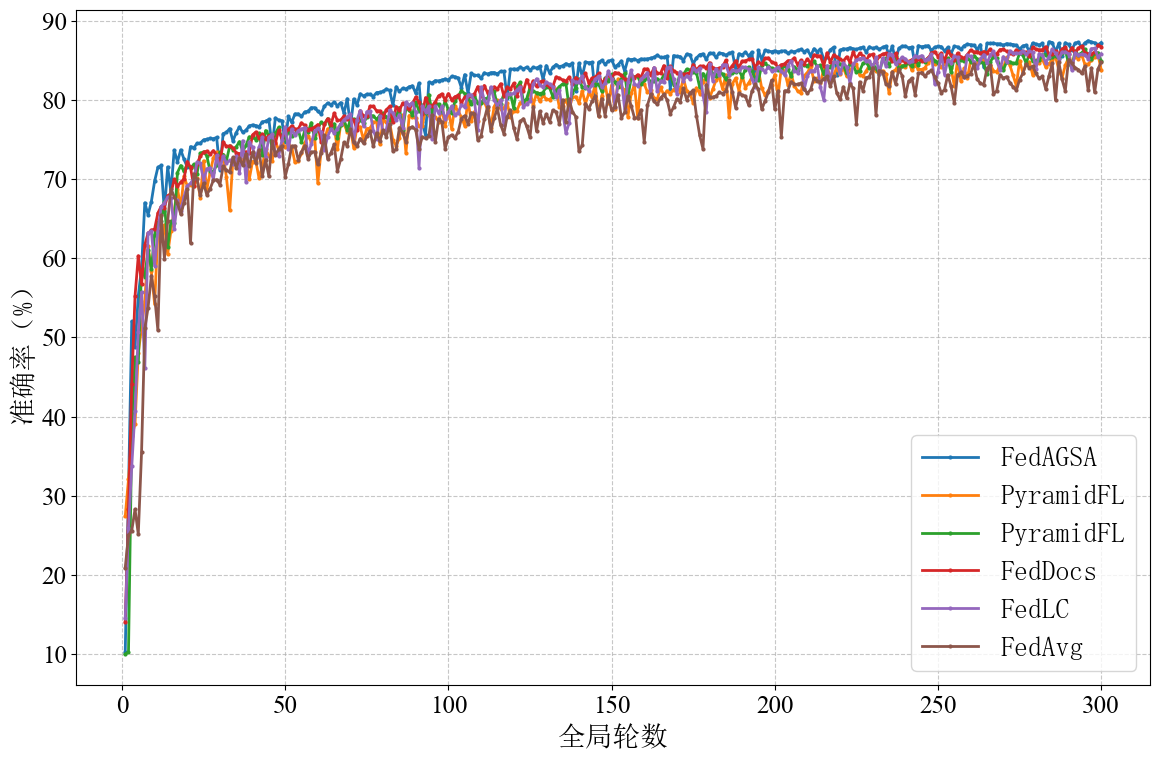

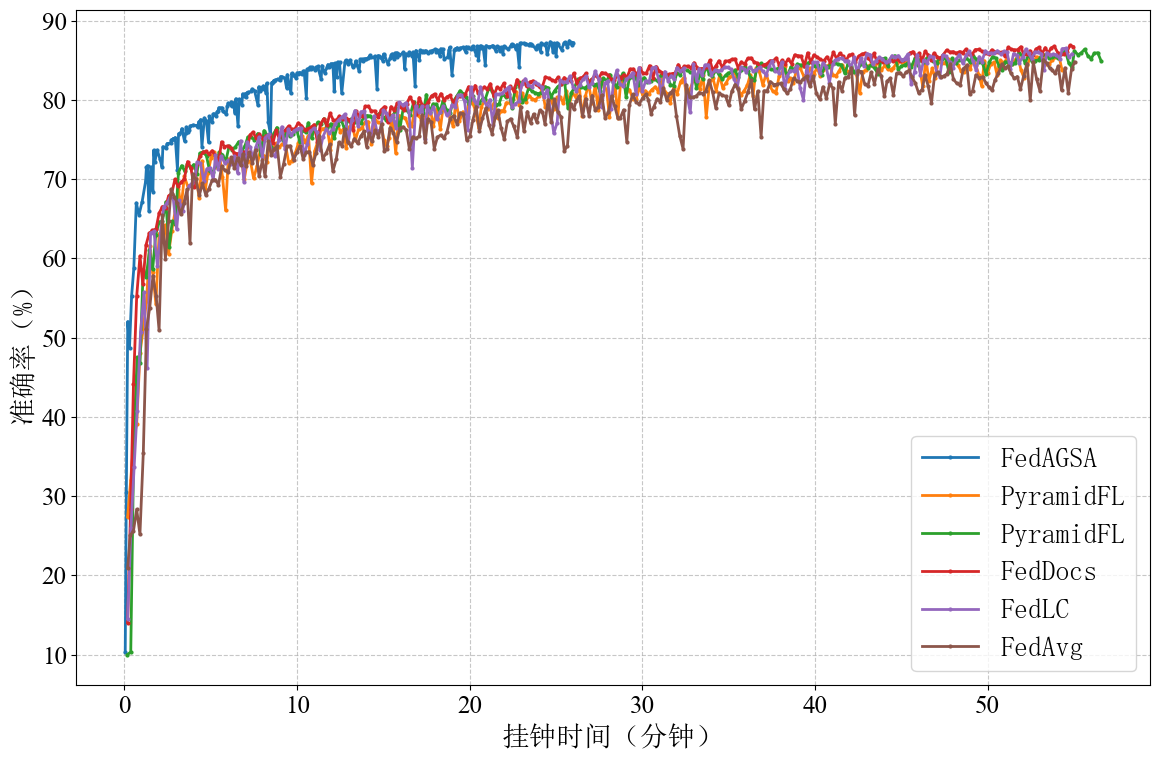

In [5]:

# 使用示例
if __name__ == "__main__":
    # 主目录路径
    main_dir = '/home/ypguo/async-FL/PK/Exp2025-FashionMNIST-Dir0.5'
    
    # 调用函数生成图表
    result = plot_federated_learning_performance(
        main_dir=main_dir,
        max_time=60,  # 60分钟
        total_rounds=300,
        save_epoch_plot=True,
        save_time_plot=True,
        fig_size=(12, 8),
        dpi=150,
        dataset_name="Fashion-MNIST",
        dir_alpha="0.1"
    )
    
    # 输出加载情况总结
    print(f"\n成功加载的算法: {len(result['loaded_algorithms'])}")
    print(f"跳过的算法: {len(result['skipped_algorithms'])}")
    